# Part 3: muP Scaling and Extrapolation

This notebook implements muP (Maximal Update Parameterization) for the GPT model, runs a learning rate sweep, trains all 5 model sizes, compares against standard parameterization from Part 2, and performs scaling law extrapolation.

It loads the tokenizer and data from Part 1 and the standard parameterization results from Part 2. Make sure both are complete before running this.

Steps:
1. Load data, tokenizer, and Part 2 results
2. Define GPT model with muP reparameterization
3. Learning rate sweep on the Tiny muP model
4. Train all 5 model sizes with muP
5. Compare standard vs muP scaling curves
6. Scaling law extrapolation with uncertainty


In [1]:
!pip install tokenizers matplotlib numpy tqdm scipy mup -q

In [2]:
import os
import json
import math
import time
import copy
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from tokenizers import Tokenizer
from scipy.optimize import curve_fit

import mup
from mup import MuReadout, make_base_shapes, set_base_shapes, MuAdamW

# UPDATE THIS to match your project directory
PROJECT_DIR = Path("ml_final_project")

DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
PLOT_DIR = PROJECT_DIR / "plots"

for d in [OUTPUT_DIR, PLOT_DIR]:
    d.mkdir(exist_ok=True, parents=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
if DEVICE == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
  GPU: NVIDIA A100-SXM4-40GB
  Memory: 42.4 GB


## Step 1: Load Data, Tokenizer, and Part 2 Results

In [3]:
# Load tokenizer
tokenizer_path = DATA_DIR / "svg_tokenizer.json"
tokenizer = Tokenizer.from_file(str(tokenizer_path))
VOCAB_SIZE = tokenizer.get_vocab_size()
print(f"Loaded tokenizer, vocab size: {VOCAB_SIZE}")

# Check binary files
for split in ["train", "val", "test"]:
    fpath = DATA_DIR / f"{split}.bin"
    data = np.memmap(str(fpath), dtype=np.uint16, mode='r')
    print(f"  {split}.bin: {len(data):,} tokens")

# Load Part 2 results for comparison later
part2_summary_path = OUTPUT_DIR / "part2_summary.json"
with open(part2_summary_path, "r") as f:
    part2_summary = json.load(f)

print(f"\nLoaded Part 2 results")
print(f"  Best LR from Part 2: {part2_summary['best_lr']}")
print(f"  Models: {list(part2_summary['models'].keys())}")
for name, info in part2_summary["models"].items():
    print(f"    {name}: {info['n_params']:,} params, val loss = {info['final_val_loss']:.4f}")

Loaded tokenizer, vocab size: 4096
  train.bin: 116,379,858 tokens
  val.bin: 1,181,388 tokens
  test.bin: 1,191,293 tokens

Loaded Part 2 results
  Best LR from Part 2: 0.01
  Models: ['Tiny', 'Small', 'Medium', 'Large', 'XL']
    Tiny: 1,350,400 params, val loss = 1.2294
    Small: 3,505,152 params, val loss = 1.0506
    Medium: 12,318,720 params, val loss = 0.9470
    Large: 33,753,088 params, val loss = 1.0668
    XL: 88,398,336 params, val loss = 1.3667


## Step 2: Model and Training Configuration

In [4]:
BLOCK_SIZE = 256
BATCH_SIZE = 64
DROPOUT = 0.1

MODEL_CONFIGS = {
    "Tiny":   {"d_model": 128,  "n_layers": 4,  "n_heads": 4,  "d_ff": 512},
    "Small":  {"d_model": 192,  "n_layers": 6,  "n_heads": 6,  "d_ff": 768},
    "Medium": {"d_model": 384,  "n_layers": 6,  "n_heads": 6,  "d_ff": 1536},
    "Large":  {"d_model": 512,  "n_layers": 10, "n_heads": 8,  "d_ff": 2048},
    "XL":     {"d_model": 768,  "n_layers": 12, "n_heads": 12, "d_ff": 3072},
}

# Base width for muP. This is the width of the smallest model.
# muP transfers hyperparameters from this base width to wider models.
BASE_D_MODEL = 128

print(f"Block size: {BLOCK_SIZE}")
print(f"Batch size: {BATCH_SIZE} sequences ({BATCH_SIZE * BLOCK_SIZE:,} tokens per step)")
print(f"muP base width: {BASE_D_MODEL}")

Block size: 256
Batch size: 64 sequences (16,384 tokens per step)
muP base width: 128


## Step 3: Data Loader

In [5]:
class SVGDataLoader:
    def __init__(self, split, block_size, batch_size, device):
        data_path = DATA_DIR / f"{split}.bin"
        self.data = np.memmap(str(data_path), dtype=np.uint16, mode='r')
        self.block_size = block_size
        self.batch_size = batch_size
        self.device = device
        self.n_tokens = len(self.data)
        self.n_batches = max(1, (self.n_tokens - block_size) // (batch_size * block_size))

    def get_batch(self):
        ix = torch.randint(len(self.data) - self.block_size - 1, (self.batch_size,))
        x = torch.stack([torch.from_numpy(self.data[i:i+self.block_size].astype(np.int64)) for i in ix])
        y = torch.stack([torch.from_numpy(self.data[i+1:i+1+self.block_size].astype(np.int64)) for i in ix])
        return x.to(self.device), y.to(self.device)

print("Data loader defined")

Data loader defined


## Step 4: GPT Model with muP

Key differences from standard parameterization:
- Output layer uses MuReadout instead of nn.Linear (scales output by width ratio)
- Attention uses 1/d scaling instead of 1/sqrt(d) as required by muP for transformers
- Initialization and per layer learning rates are handled by mup.set_base_shapes
- Optimizer uses MuAdamW which applies muP learning rate multipliers per layer


In [6]:
class MuPCausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, max_seq_len, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.d_model = d_model
        self.c_attn = nn.Linear(d_model, 3 * d_model)
        self.c_proj = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.register_buffer("bias", torch.tril(torch.ones(max_seq_len, max_seq_len))
                             .view(1, 1, max_seq_len, max_seq_len))

    def forward(self, x):
        B, T, C = x.size()
        qkv = self.c_attn(x)
        q, k, v = qkv.split(C, dim=2)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        # muP for transformers: use 1/d instead of 1/sqrt(d) for attention scaling
        att = (q @ k.transpose(-2, -1)) * (1.0 / self.head_dim)
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y


class MuPMLP(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.c_fc = nn.Linear(d_model, d_ff)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))


class MuPTransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, max_seq_len, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MuPCausalSelfAttention(d_model, n_heads, max_seq_len, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = MuPMLP(d_model, d_ff, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class MuPGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, max_seq_len, dropout=0.1):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            MuPTransformerBlock(d_model, n_heads, d_ff, max_seq_len, dropout)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        # MuReadout replaces the final nn.Linear for muP
        self.head = MuReadout(d_model, vocab_size, bias=False)

        # Note: no weight tying with MuReadout as it handles scaling differently
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        assert T <= self.max_seq_len
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        tok_emb = self.tok_emb(idx)
        pos_emb = self.pos_emb(pos)
        x = self.drop(tok_emb + pos_emb)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

print("muP GPT model defined")

muP GPT model defined


## Step 5: Set Up muP Base Shapes

muP needs to know the base model width so it can compute the correct scaling factors for wider models. We create a base model (smallest width) and a delta model (slightly wider) to define the shape mapping.


In [7]:
def make_mup_model(config, set_mup=True):
    """Create a muP model with base shapes properly configured."""
    d_model = config["d_model"]
    n_layers = config["n_layers"]
    n_heads = config["n_heads"]
    d_ff = config["d_ff"]

    # Create the target model
    model = MuPGPT(
        vocab_size=VOCAB_SIZE,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        max_seq_len=BLOCK_SIZE,
        dropout=DROPOUT,
    )

    if set_mup:
        # Base model: same depth, base width
        base_config = {
            "d_model": BASE_D_MODEL,
            "n_layers": n_layers,
            "n_heads": max(1, BASE_D_MODEL // (d_model // n_heads)),  # keep head dim similar
            "d_ff": BASE_D_MODEL * 4,
        }

        base_model = MuPGPT(
            vocab_size=VOCAB_SIZE,
            d_model=base_config["d_model"],
            n_heads=base_config["n_heads"],
            n_layers=base_config["n_layers"],
            d_ff=base_config["d_ff"],
            max_seq_len=BLOCK_SIZE,
            dropout=DROPOUT,
        )

        # Delta model: slightly wider than base to define scaling direction
        delta_config = {
            "d_model": BASE_D_MODEL * 2,
            "n_layers": n_layers,
            "n_heads": max(1, (BASE_D_MODEL * 2) // (d_model // n_heads)),
            "d_ff": BASE_D_MODEL * 8,
        }

        delta_model = MuPGPT(
            vocab_size=VOCAB_SIZE,
            d_model=delta_config["d_model"],
            n_heads=delta_config["n_heads"],
            n_layers=delta_config["n_layers"],
            d_ff=delta_config["d_ff"],
            max_seq_len=BLOCK_SIZE,
            dropout=DROPOUT,
        )

        set_base_shapes(model, base_model, delta=delta_model)

        del base_model, delta_model

    return model

# Test it
for name, cfg in MODEL_CONFIGS.items():
    model = make_mup_model(cfg, set_mup=True)
    print(f"  {name}: {model.count_params():,} params (muP configured)")
    del model

torch.cuda.empty_cache() if torch.cuda.is_available() else None

  Tiny: 1,874,688 params (muP configured)
  Small: 4,291,584 params (muP configured)
  Medium: 13,891,584 params (muP configured)
  Large: 35,850,240 params (muP configured)
  XL: 91,544,064 params (muP configured)


## Step 6: Training Function for muP

Same training loop as Part 2 but uses MuAdamW optimizer which applies the correct per layer learning rate multipliers under muP.


In [8]:
def get_lr(step, warmup_steps, max_steps, max_lr, min_lr):
    if step < warmup_steps:
        return max_lr * (step + 1) / warmup_steps
    if step >= max_steps:
        return min_lr
    progress = (step - warmup_steps) / (max_steps - warmup_steps)
    return min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * progress))


@torch.no_grad()
def estimate_val_loss(model, val_loader, eval_iters=50):
    model.eval()
    losses = []
    for _ in range(eval_iters):
        x, y = val_loader.get_batch()
        _, loss = model(x, y)
        losses.append(loss.item())
    model.train()
    return np.mean(losses)


def train_mup_model(model_name, config, lr, num_epochs=1, log_interval=100, eval_interval=500, eval_iters=50):
    print(f"\nTraining {model_name} (muP) with LR {lr:.2e} on {DEVICE}")

    model = make_mup_model(config, set_mup=True).to(DEVICE)
    n_params = model.count_params()
    print(f"  Parameters: {n_params:,}")

    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()

    train_loader = SVGDataLoader("train", BLOCK_SIZE, BATCH_SIZE, DEVICE)
    val_loader = SVGDataLoader("val", BLOCK_SIZE, BATCH_SIZE, DEVICE)

    tokens_per_step = BATCH_SIZE * BLOCK_SIZE
    steps_per_epoch = train_loader.n_tokens // tokens_per_step
    total_steps = steps_per_epoch * num_epochs
    warmup_steps = max(1, total_steps // 20)
    min_lr = lr * 0.1

    print(f"  Train tokens: {train_loader.n_tokens:,}")
    print(f"  Steps per epoch: {steps_per_epoch:,}")
    print(f"  Total steps: {total_steps:,}")
    print(f"  Warmup steps: {warmup_steps}")

    # MuAdamW applies muP scaling to per layer learning rates
    optimizer = MuAdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=0.1)

    train_losses = []
    val_losses = []
    total_tokens_processed = 0
    model.train()
    t_start = time.time()

    for step in range(total_steps):
        t_step = time.time()

        current_lr = get_lr(step, warmup_steps, total_steps, lr, min_lr)
        for pg in optimizer.param_groups:
            pg['lr'] = current_lr

        x, y = train_loader.get_batch()
        _, loss = model(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        total_tokens_processed += tokens_per_step
        step_dt = time.time() - t_step
        train_losses.append({"step": step, "loss": loss.item(), "lr": current_lr})

        if step % log_interval == 0:
            tok_per_sec = tokens_per_step / step_dt
            print(f"  Step {step:>6} of {total_steps} | loss {loss.item():.4f} | lr {current_lr:.2e} | {tok_per_sec:,.0f} tok/s")

        if step > 0 and step % eval_interval == 0:
            vl = estimate_val_loss(model, val_loader, eval_iters)
            val_losses.append({"step": step, "val_loss": vl})
            print(f"  Validation loss at step {step}: {vl:.4f}")

    final_val_loss = estimate_val_loss(model, val_loader, eval_iters)
    val_losses.append({"step": total_steps, "val_loss": final_val_loss})

    elapsed = time.time() - t_start
    avg_tok_per_sec = total_tokens_processed / elapsed

    gpu_mem_mb = 0
    if DEVICE == "cuda":
        gpu_mem_mb = torch.cuda.max_memory_allocated() / 1e6

    results = {
        "model_name": model_name,
        "n_params": n_params,
        "config": config,
        "lr": lr,
        "final_val_loss": final_val_loss,
        "final_train_loss": train_losses[-1]["loss"],
        "train_losses": train_losses,
        "val_losses": val_losses,
        "wall_time_sec": elapsed,
        "tokens_per_sec": avg_tok_per_sec,
        "gpu_mem_mb": gpu_mem_mb,
        "total_steps": total_steps,
        "total_tokens": total_tokens_processed,
    }

    print(f"  Finished {model_name} in {elapsed:.1f} seconds")
    print(f"  Final validation loss: {final_val_loss:.4f}")
    print(f"  Throughput: {avg_tok_per_sec:,.0f} tokens per second")
    print(f"  Peak GPU memory: {gpu_mem_mb:.0f} MB")

    del model, optimizer, train_loader, val_loader
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    return results

print("muP training function defined")

muP training function defined


## Step 7: Learning Rate Sweep on Tiny muP Model

Same sweep protocol as Part 2. Testing 7 LRs on log scale.


In [9]:
LR_CANDIDATES = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

mup_lr_sweep_results = []

for lr_candidate in LR_CANDIDATES:
    print(f"\nTesting LR = {lr_candidate:.1e} (muP)")
    result = train_mup_model(
        model_name=f"Tiny_muP_lr{lr_candidate:.0e}",
        config=MODEL_CONFIGS["Tiny"],
        lr=lr_candidate,
        num_epochs=1,
        log_interval=200,
        eval_interval=500,
    )
    mup_lr_sweep_results.append({
        "lr": lr_candidate,
        "val_loss": result["final_val_loss"],
        "train_loss": result["final_train_loss"],
    })

best_mup_lr_entry = min(mup_lr_sweep_results, key=lambda x: x["val_loss"])
BEST_MUP_LR = best_mup_lr_entry["lr"]

print(f"\nmuP learning rate sweep results:")
for r in mup_lr_sweep_results:
    marker = " (best)" if r["lr"] == BEST_MUP_LR else ""
    print(f"  LR {r['lr']:.1e}: val loss = {r['val_loss']:.4f}, train loss = {r['train_loss']:.4f}{marker}")

print(f"\nBest muP learning rate: {BEST_MUP_LR:.1e}")
print(f"Best SP learning rate from Part 2: {part2_summary['best_lr']}")

with open(OUTPUT_DIR / "mup_lr_sweep_results.json", "w") as f:
    json.dump(mup_lr_sweep_results, f, indent=2)
print("muP LR sweep results saved")


Testing LR = 1.0e-05 (muP)

Training Tiny_muP_lr1e-05 (muP) with LR 1.00e-05 on cuda
  Parameters: 1,874,688
  Train tokens: 116,379,858
  Steps per epoch: 7,103
  Total steps: 7,103
  Warmup steps: 355
  Step      0 of 7103 | loss 8.3424 | lr 2.82e-08 | 6,878 tok/s
  Step    200 of 7103 | loss 7.7045 | lr 5.66e-06 | 1,131,129 tok/s
  Step    400 of 7103 | loss 7.2311 | lr 1.00e-05 | 1,121,529 tok/s
  Validation loss at step 500: 6.9501
  Step    600 of 7103 | loss 6.7845 | lr 9.97e-06 | 1,146,127 tok/s
  Step    800 of 7103 | loss 6.4135 | lr 9.90e-06 | 1,144,295 tok/s
  Step   1000 of 7103 | loss 6.0585 | lr 9.80e-06 | 1,076,568 tok/s
  Validation loss at step 1000: 5.9979
  Step   1200 of 7103 | loss 5.7151 | lr 9.66e-06 | 1,160,214 tok/s
  Step   1400 of 7103 | loss 5.3972 | lr 9.48e-06 | 1,191,371 tok/s
  Validation loss at step 1500: 5.2378
  Step   1600 of 7103 | loss 5.1074 | lr 9.27e-06 | 1,163,495 tok/s
  Step   1800 of 7103 | loss 4.8922 | lr 9.02e-06 | 1,163,022 tok/s
  St

## Step 8: LR Sweep Comparison Plot (SP vs muP)

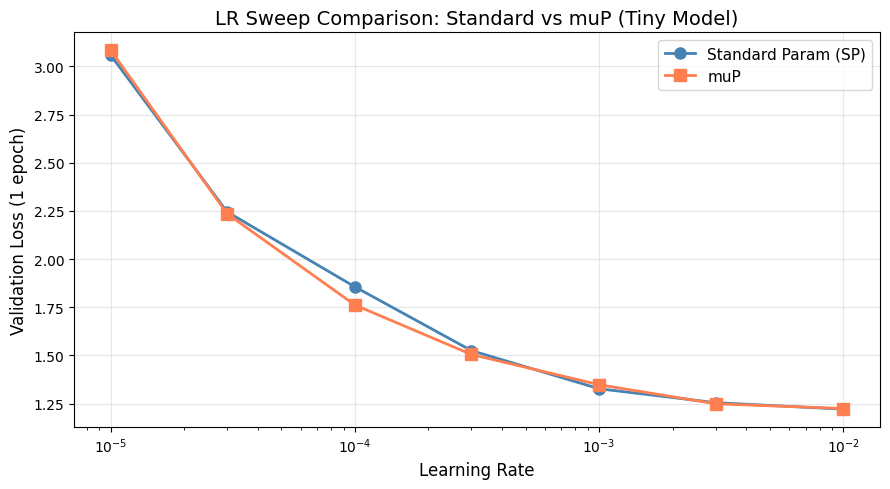

LR sweep comparison plot saved


In [10]:
# Load SP sweep results from Part 2
sp_lr_sweep = part2_summary["lr_sweep"]

fig, ax = plt.subplots(figsize=(9, 5))

sp_lrs = [r["lr"] for r in sp_lr_sweep]
sp_vl = [r["val_loss"] for r in sp_lr_sweep]
ax.semilogx(sp_lrs, sp_vl, 'o-', color='steelblue', markersize=8, linewidth=2, label='Standard Param (SP)')

mup_lrs = [r["lr"] for r in mup_lr_sweep_results]
mup_vl = [r["val_loss"] for r in mup_lr_sweep_results]
ax.semilogx(mup_lrs, mup_vl, 's-', color='coral', markersize=8, linewidth=2, label='muP')

ax.set_xlabel("Learning Rate", fontsize=12)
ax.set_ylabel("Validation Loss (1 epoch)", fontsize=12)
ax.set_title("LR Sweep Comparison: Standard vs muP (Tiny Model)", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(str(PLOT_DIR / "lr_sweep_sp_vs_mup.png"), dpi=150)
plt.show()
print("LR sweep comparison plot saved")

## Step 9: Train All 5 Model Sizes with muP

Using the best muP LR from the sweep, training all models for 1 epoch.
The key idea of muP is that this LR should transfer well to wider models without retuning.


In [11]:
mup_results = {}

for model_name, config in MODEL_CONFIGS.items():
    result = train_mup_model(
        model_name=f"{model_name}_muP",
        config=config,
        lr=BEST_MUP_LR,
        num_epochs=1,
        log_interval=100,
        eval_interval=500,
    )
    mup_results[model_name] = result

with open(OUTPUT_DIR / "mup_scaling_results.json", "w") as f:
    json.dump(mup_results, f, indent=2, default=str)

print("\nAll muP models trained. Summary:")
print(f"{'Model':<10} {'Params':>12} {'muP Val':>10} {'SP Val':>10} {'muP Time':>10}")
for name in MODEL_CONFIGS:
    mr = mup_results[name]
    sp_vl = part2_summary["models"][name]["final_val_loss"]
    print(f"{name:<10} {mr['n_params']:>12,} {mr['final_val_loss']:>10.4f} {sp_vl:>10.4f} {mr['wall_time_sec']:>9.0f}s")


Training Tiny_muP (muP) with LR 1.00e-02 on cuda
  Parameters: 1,874,688
  Train tokens: 116,379,858
  Steps per epoch: 7,103
  Total steps: 7,103
  Warmup steps: 355
  Step      0 of 7103 | loss 8.3553 | lr 2.82e-05 | 771,895 tok/s
  Step    100 of 7103 | loss 2.7503 | lr 2.85e-03 | 1,194,498 tok/s
  Step    200 of 7103 | loss 2.2826 | lr 5.66e-03 | 1,208,807 tok/s
  Step    300 of 7103 | loss 2.0184 | lr 8.48e-03 | 1,234,120 tok/s
  Step    400 of 7103 | loss 2.0238 | lr 1.00e-02 | 1,198,561 tok/s
  Step    500 of 7103 | loss 1.8383 | lr 9.99e-03 | 1,183,594 tok/s
  Validation loss at step 500: 1.7582
  Step    600 of 7103 | loss 1.6744 | lr 9.97e-03 | 1,207,236 tok/s
  Step    700 of 7103 | loss 1.6609 | lr 9.94e-03 | 1,164,559 tok/s
  Step    800 of 7103 | loss 1.6580 | lr 9.90e-03 | 1,136,817 tok/s
  Step    900 of 7103 | loss 1.6226 | lr 9.86e-03 | 1,188,795 tok/s
  Step   1000 of 7103 | loss 1.5590 | lr 9.80e-03 | 1,189,042 tok/s
  Validation loss at step 1000: 1.5821
  Step   

## Step 10: Scaling Curves Comparison with Power Law Fits

Plotting both SP and muP scaling curves on the same graph. Fitting power law L = a * N^(negative alpha) + c to both.


Power law fits:
  SP: L = 1000000.0000 * N^(-1.1619) + 1.1104, alpha = 1.1619, R2 = 0.0412
  muP: L = 72852.3039 * N^(-0.8665) + 0.9522, alpha = 0.8665, R2 = 0.9598


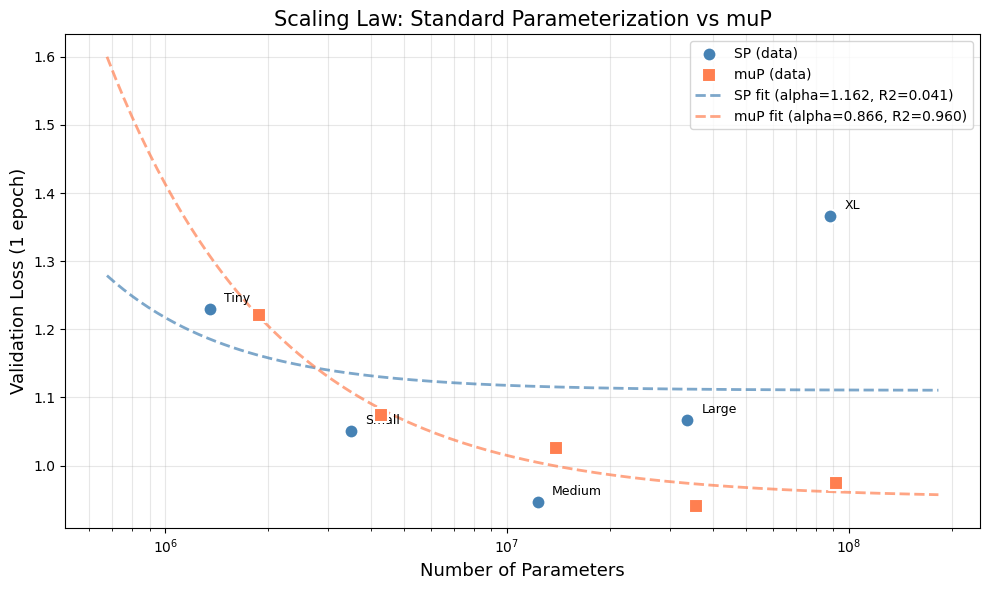

Comparison scaling plot saved


In [12]:
def power_law(N, a, alpha, c):
    return a * np.power(N, -alpha) + c

def fit_power_law(param_counts, losses, label):
    try:
        popt, pcov = curve_fit(
            power_law, param_counts, losses,
            p0=[10.0, 0.1, 1.0],
            bounds=([0, 0, 0], [1e6, 2.0, 10.0]),
            maxfev=10000,
        )
        a, alpha, c = popt
        perr = np.sqrt(np.diag(pcov))
        predicted = power_law(param_counts, *popt)
        ss_res = np.sum((losses - predicted) ** 2)
        ss_tot = np.sum((losses - np.mean(losses)) ** 2)
        r2 = 1 - ss_res / ss_tot
        print(f"  {label}: L = {a:.4f} * N^({-alpha:.4f}) + {c:.4f}, alpha = {alpha:.4f}, R2 = {r2:.4f}")
        return popt, pcov, r2, True
    except Exception as e:
        print(f"  {label}: fit failed ({e})")
        return None, None, None, False

model_names = list(MODEL_CONFIGS.keys())

# SP data from Part 2
sp_params = np.array([part2_summary["models"][n]["n_params"] for n in model_names])
sp_losses = np.array([part2_summary["models"][n]["final_val_loss"] for n in model_names])

# muP data
mup_params = np.array([mup_results[n]["n_params"] for n in model_names])
mup_losses = np.array([mup_results[n]["final_val_loss"] for n in model_names])

print("Power law fits:")
sp_popt, sp_pcov, sp_r2, sp_fit_ok = fit_power_law(sp_params, sp_losses, "SP")
mup_popt, mup_pcov, mup_r2, mup_fit_ok = fit_power_law(mup_params, mup_losses, "muP")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(sp_params, sp_losses, s=100, c='steelblue', zorder=5, edgecolors='white', linewidth=1.5, label='SP (data)')
ax.scatter(mup_params, mup_losses, s=100, c='coral', zorder=5, edgecolors='white', linewidth=1.5, marker='s', label='muP (data)')

x_smooth = np.logspace(np.log10(min(sp_params.min(), mup_params.min()) * 0.5),
                        np.log10(max(sp_params.max(), mup_params.max()) * 2), 200)

if sp_fit_ok:
    y_sp = power_law(x_smooth, *sp_popt)
    sp_alpha = sp_popt[1]
    ax.plot(x_smooth, y_sp, '--', color='steelblue', linewidth=2, alpha=0.7,
            label=f'SP fit (alpha={sp_alpha:.3f}, R2={sp_r2:.3f})')

if mup_fit_ok:
    y_mup = power_law(x_smooth, *mup_popt)
    mup_alpha = mup_popt[1]
    ax.plot(x_smooth, y_mup, '--', color='coral', linewidth=2, alpha=0.7,
            label=f'muP fit (alpha={mup_alpha:.3f}, R2={mup_r2:.3f})')

for i, name in enumerate(model_names):
    ax.annotate(name, (sp_params[i], sp_losses[i]), textcoords="offset points", xytext=(10, 5), fontsize=9)

ax.set_xscale('log')
ax.set_xlabel("Number of Parameters", fontsize=13)
ax.set_ylabel("Validation Loss (1 epoch)", fontsize=13)
ax.set_title("Scaling Law: Standard Parameterization vs muP", fontsize=15)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
fig.savefig(str(PLOT_DIR / "scaling_sp_vs_mup.png"), dpi=150)
plt.show()
print("Comparison scaling plot saved")

## Step 11: Training Loss Curves (muP)

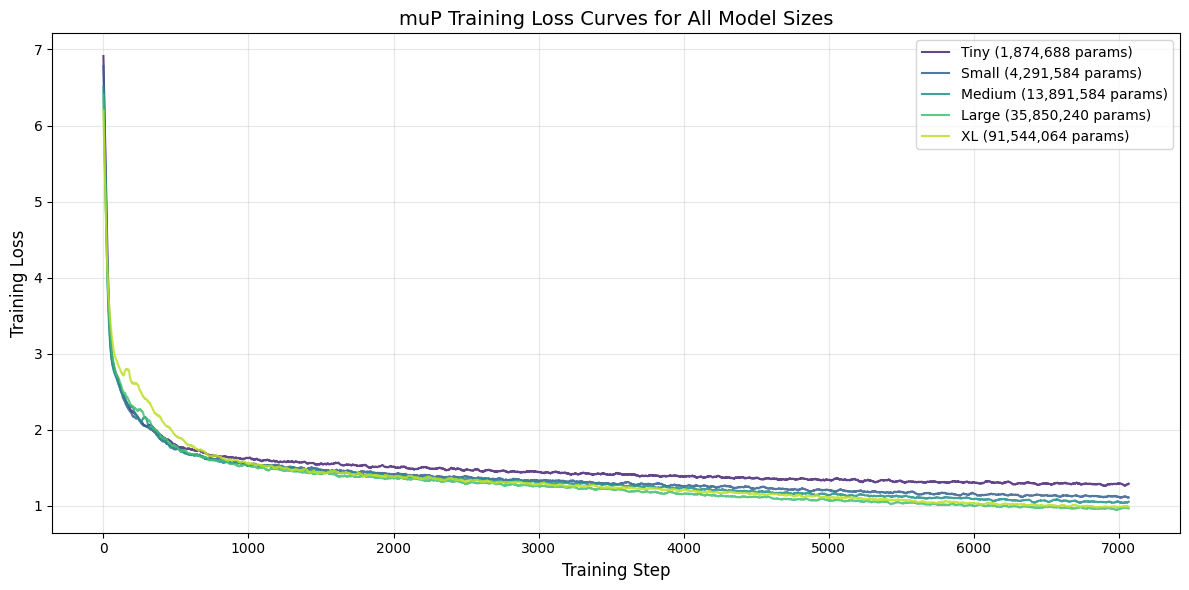

muP training curves plot saved


In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(MODEL_CONFIGS)))

for i, (name, result) in enumerate(mup_results.items()):
    steps = [t["step"] for t in result["train_losses"]]
    losses = [t["loss"] for t in result["train_losses"]]
    window = max(1, len(losses) // 200)
    if window > 1:
        smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
        smooth_steps = steps[:len(smoothed)]
    else:
        smoothed = losses
        smooth_steps = steps
    ax.plot(smooth_steps, smoothed, color=colors[i], linewidth=1.5, alpha=0.85,
            label=f"{name} ({result['n_params']:,} params)")

ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Training Loss", fontsize=12)
ax.set_title("muP Training Loss Curves for All Model Sizes", fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(str(PLOT_DIR / "mup_training_curves.png"), dpi=150)
plt.show()
print("muP training curves plot saved")

## Step 12: Scaling Law Extrapolation

Using the better power law fit (whichever has higher R2) to predict validation loss for a model with 10x more parameters than the XL model.


Extrapolation using muP power law fit:
  Best fit: L = 72852.3039 * N^(-0.8665) + 0.9522
  R squared: 0.9598

  XL model: 88,398,336 parameters, val loss = 1.3667
  Target model: 883,983,360 parameters (10x XL)
  Predicted validation loss: 0.9535
  95 percent confidence interval: [0.8881, 1.0190]
  Standard error: 0.0334


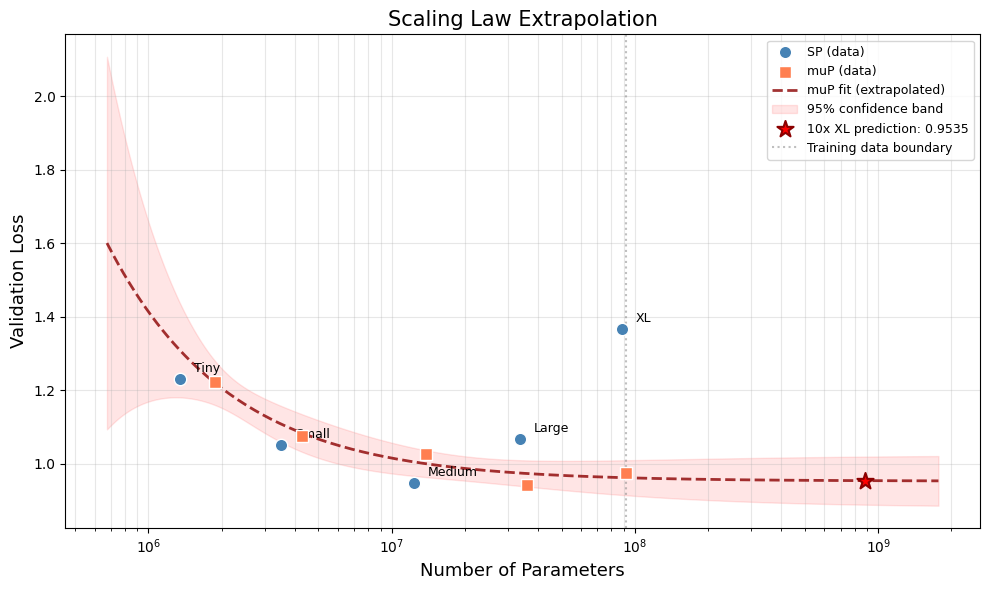

Extrapolation plot saved


In [14]:
# Pick the better fit
if sp_fit_ok and mup_fit_ok:
    if mup_r2 >= sp_r2:
        best_popt, best_pcov, best_r2, best_label = mup_popt, mup_pcov, mup_r2, "muP"
    else:
        best_popt, best_pcov, best_r2, best_label = sp_popt, sp_pcov, sp_r2, "SP"
elif sp_fit_ok:
    best_popt, best_pcov, best_r2, best_label = sp_popt, sp_pcov, sp_r2, "SP"
elif mup_fit_ok:
    best_popt, best_pcov, best_r2, best_label = mup_popt, mup_pcov, mup_r2, "muP"
else:
    print("Neither fit succeeded. Cannot extrapolate.")
    best_popt = None

if best_popt is not None:
    # XL param count
    xl_params = part2_summary["models"]["XL"]["n_params"]
    target_params = xl_params * 10

    # Predicted loss
    predicted_loss = power_law(target_params, *best_popt)

    # Uncertainty from covariance matrix using error propagation
    # Compute Jacobian of power_law with respect to (a, alpha, c) at target_params
    a, alpha, c = best_popt
    J = np.array([
        np.power(target_params, -alpha),                        # dL/da
        -a * np.power(target_params, -alpha) * np.log(target_params),  # dL/dalpha
        1.0,                                                     # dL/dc
    ])
    predicted_variance = J @ best_pcov @ J
    predicted_std = np.sqrt(predicted_variance)

    print(f"Extrapolation using {best_label} power law fit:")
    print(f"  Best fit: L = {a:.4f} * N^({-alpha:.4f}) + {c:.4f}")
    print(f"  R squared: {best_r2:.4f}")
    print(f"")
    print(f"  XL model: {xl_params:,} parameters, val loss = {part2_summary['models']['XL']['final_val_loss']:.4f}")
    print(f"  Target model: {target_params:,} parameters (10x XL)")
    print(f"  Predicted validation loss: {predicted_loss:.4f}")
    print(f"  95 percent confidence interval: [{predicted_loss - 1.96*predicted_std:.4f}, {predicted_loss + 1.96*predicted_std:.4f}]")
    print(f"  Standard error: {predicted_std:.4f}")

    # Plot extrapolation
    fig, ax = plt.subplots(figsize=(10, 6))

    # Data points
    if sp_fit_ok:
        ax.scatter(sp_params, sp_losses, s=80, c='steelblue', zorder=5, edgecolors='white', label='SP (data)')
    if mup_fit_ok:
        ax.scatter(mup_params, mup_losses, s=80, c='coral', zorder=5, edgecolors='white', marker='s', label='muP (data)')

    # Fit curve extended to extrapolation
    x_extrap = np.logspace(np.log10(min(sp_params.min(), mup_params.min()) * 0.5),
                            np.log10(target_params * 2), 300)
    y_extrap = power_law(x_extrap, *best_popt)

    # Confidence band via error propagation at each point
    y_std = []
    for xp in x_extrap:
        Jp = np.array([
            np.power(xp, -alpha),
            -a * np.power(xp, -alpha) * np.log(xp),
            1.0,
        ])
        var_p = Jp @ best_pcov @ Jp
        y_std.append(np.sqrt(max(0, var_p)))
    y_std = np.array(y_std)

    ax.plot(x_extrap, y_extrap, '--', color='darkred', linewidth=2, alpha=0.8, label=f'{best_label} fit (extrapolated)')
    ax.fill_between(x_extrap, y_extrap - 1.96*y_std, y_extrap + 1.96*y_std,
                     color='red', alpha=0.1, label='95% confidence band')

    # Extrapolation point
    ax.scatter([target_params], [predicted_loss], s=150, c='red', zorder=6, marker='*',
               edgecolors='darkred', linewidth=1.5, label=f'10x XL prediction: {predicted_loss:.4f}')

    # Vertical line at extrapolation boundary
    max_trained = max(sp_params.max(), mup_params.max())
    ax.axvline(max_trained, color='gray', linestyle=':', alpha=0.5, label='Training data boundary')

    for i, name in enumerate(model_names):
        ax.annotate(name, (sp_params[i], sp_losses[i]), textcoords="offset points", xytext=(10, 5), fontsize=9)

    ax.set_xscale('log')
    ax.set_xlabel("Number of Parameters", fontsize=13)
    ax.set_ylabel("Validation Loss", fontsize=13)
    ax.set_title("Scaling Law Extrapolation", fontsize=15)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    fig.savefig(str(PLOT_DIR / "scaling_extrapolation.png"), dpi=150)
    plt.show()
    print("Extrapolation plot saved")

## Step 13: Save Summary

In [15]:
summary = {
    "best_mup_lr": BEST_MUP_LR,
    "best_sp_lr": part2_summary["best_lr"],
    "mup_lr_sweep": mup_lr_sweep_results,
    "mup_scaling": {},
    "sp_scaling": {},
    "comparison": {},
}

if sp_fit_ok:
    summary["sp_scaling"] = {
        "alpha": float(sp_popt[1]),
        "a": float(sp_popt[0]),
        "c": float(sp_popt[2]),
        "r_squared": float(sp_r2),
    }

if mup_fit_ok:
    summary["mup_scaling"] = {
        "alpha": float(mup_popt[1]),
        "a": float(mup_popt[0]),
        "c": float(mup_popt[2]),
        "r_squared": float(mup_r2),
    }

for name in MODEL_CONFIGS:
    mr = mup_results[name]
    sp_vl = part2_summary["models"][name]["final_val_loss"]
    summary["comparison"][name] = {
        "n_params": mr["n_params"],
        "sp_val_loss": sp_vl,
        "mup_val_loss": mr["final_val_loss"],
        "improvement": sp_vl - mr["final_val_loss"],
    }

if best_popt is not None:
    summary["extrapolation"] = {
        "method": best_label,
        "xl_params": int(xl_params),
        "target_params": int(target_params),
        "predicted_loss": float(predicted_loss),
        "confidence_interval_95": [float(predicted_loss - 1.96*predicted_std), float(predicted_loss + 1.96*predicted_std)],
        "standard_error": float(predicted_std),
    }

with open(OUTPUT_DIR / "part3_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Part 3 complete")
print("")
print(f"Best muP LR: {BEST_MUP_LR:.1e}")
print(f"Best SP LR: {part2_summary['best_lr']}")
print("")
print("Comparison (SP vs muP validation loss):")
for name in MODEL_CONFIGS:
    c = summary["comparison"][name]
    better = "muP better" if c["improvement"] > 0 else "SP better"
    print(f"  {name}: SP={c['sp_val_loss']:.4f}, muP={c['mup_val_loss']:.4f}, diff={c['improvement']:.4f} ({better})")

if sp_fit_ok:
    print(f"\nSP scaling exponent alpha: {sp_popt[1]:.4f} (R2={sp_r2:.4f})")
if mup_fit_ok:
    print(f"muP scaling exponent alpha: {mup_popt[1]:.4f} (R2={mup_r2:.4f})")

if best_popt is not None:
    print(f"\nExtrapolation (10x XL, using {best_label}):")
    print(f"  Predicted loss: {predicted_loss:.4f}")
    print(f"  95% CI: [{predicted_loss - 1.96*predicted_std:.4f}, {predicted_loss + 1.96*predicted_std:.4f}]")

print("")
print("Plots saved:")
print(f"  {PLOT_DIR / 'lr_sweep_sp_vs_mup.png'}")
print(f"  {PLOT_DIR / 'scaling_sp_vs_mup.png'}")
print(f"  {PLOT_DIR / 'mup_training_curves.png'}")
print(f"  {PLOT_DIR / 'scaling_extrapolation.png'}")
print(f"  {OUTPUT_DIR / 'part3_summary.json'}")

Part 3 complete

Best muP LR: 1.0e-02
Best SP LR: 0.01

Comparison (SP vs muP validation loss):
  Tiny: SP=1.2294, muP=1.2215, diff=0.0079 (muP better)
  Small: SP=1.0506, muP=1.0738, diff=-0.0233 (SP better)
  Medium: SP=0.9470, muP=1.0252, diff=-0.0782 (SP better)
  Large: SP=1.0668, muP=0.9412, diff=0.1257 (muP better)
  XL: SP=1.3667, muP=0.9745, diff=0.3922 (muP better)

SP scaling exponent alpha: 1.1619 (R2=0.0412)
muP scaling exponent alpha: 0.8665 (R2=0.9598)

Extrapolation (10x XL, using muP):
  Predicted loss: 0.9535
  95% CI: [0.8881, 1.0190]

Plots saved:
  ml_final_project/plots/lr_sweep_sp_vs_mup.png
  ml_final_project/plots/scaling_sp_vs_mup.png
  ml_final_project/plots/mup_training_curves.png
  ml_final_project/plots/scaling_extrapolation.png
  ml_final_project/outputs/part3_summary.json
